In [415]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [416]:
#Read the dataset
df = pd.read_csv("Electric_Vehicle_Population_Data_complete.csv")

#Print 5 rows from dataframe
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,0.0,40000.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


In [417]:
#Print shape of dataframe
print(df.shape)

#Print columns in dataframe
df.columns

(235692, 17)


Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [418]:
#Describe the numerical values in the dataset to include their count, mean, std deviation, min, max
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.000000,235692.000000,235656.000000,235656.000000,235198.000000,2.356920e+05,2.356890e+05
mean,98177.656463,2021.406658,46.262569,47088.455320,28.879519,2.353127e+08,5.298066e+10
std,2524.218661,2.991908,84.045829,16031.561011,14.904644,6.799098e+07,1.521066e+09
min,1731.000000,2000.000000,0.000000,13000.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,37000.000000,17.000000,2.053457e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,44000.000000,32.000000,2.522795e+08,5.303303e+10
75%,98374.000000,2024.000000,38.000000,50000.000000,42.000000,2.696401e+08,5.305307e+10
max,99577.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


In [419]:
#Show information about the data types, non null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

In [420]:
#Check if there are any duplicate records
df.duplicated().any()

np.False_

## Exploratory Data Analysis

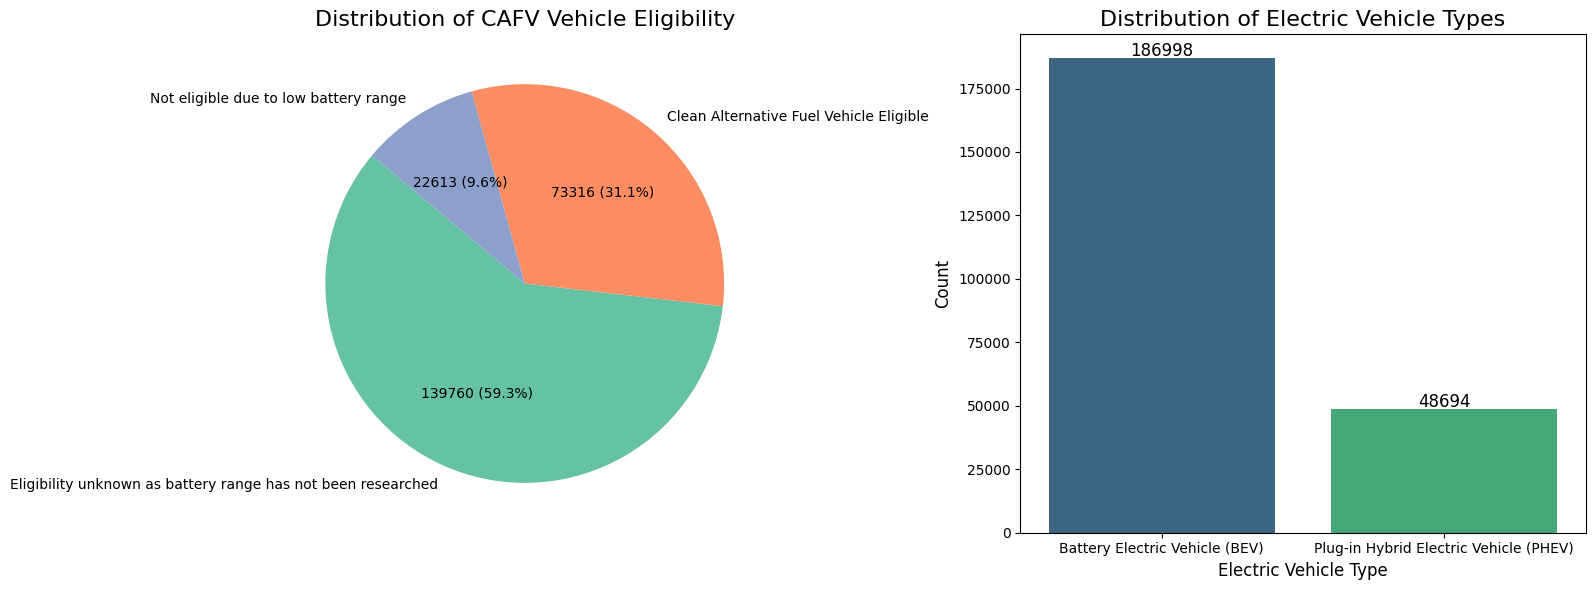

In [421]:
#Distribution of CAFV Vehicle Eligibility and Distribution of Electric Vehicle Types

import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 1 row and 2 columns for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for the distribution of CAFV vehicle counts
CAFV = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

# Function to format the actual count and percentage in the pie chart
def func(pct, allvals):
    absolute = int(pct / 100. * sum(allvals))
    return f"{absolute} ({pct:.1f}%)"  # Format to include both count and percentage

# Pie chart with rotation (90 degrees)
axes[0].pie(CAFV.values, labels=CAFV.index, autopct=lambda pct: func(pct, CAFV.values), colors=plt.cm.Set2.colors, startangle=140)
axes[0].set_title('Distribution of CAFV Vehicle Eligibility', fontsize=16)

#Barplot for the distribution of Electric Vehicle Types
ev_type_counts = df['Electric Vehicle Type'].value_counts()
sns.barplot(x=ev_type_counts.index, y=ev_type_counts.values, hue=ev_type_counts.index, palette='viridis', ax=axes[1])

#Title and labels to the bar plot
axes[1].set_title('Distribution of Electric Vehicle Types', fontsize=16)
axes[1].set_xlabel('Electric Vehicle Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

# Annotate actual values on the bar plot
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points') 

# Display the plot
plt.tight_layout()
plt.show()


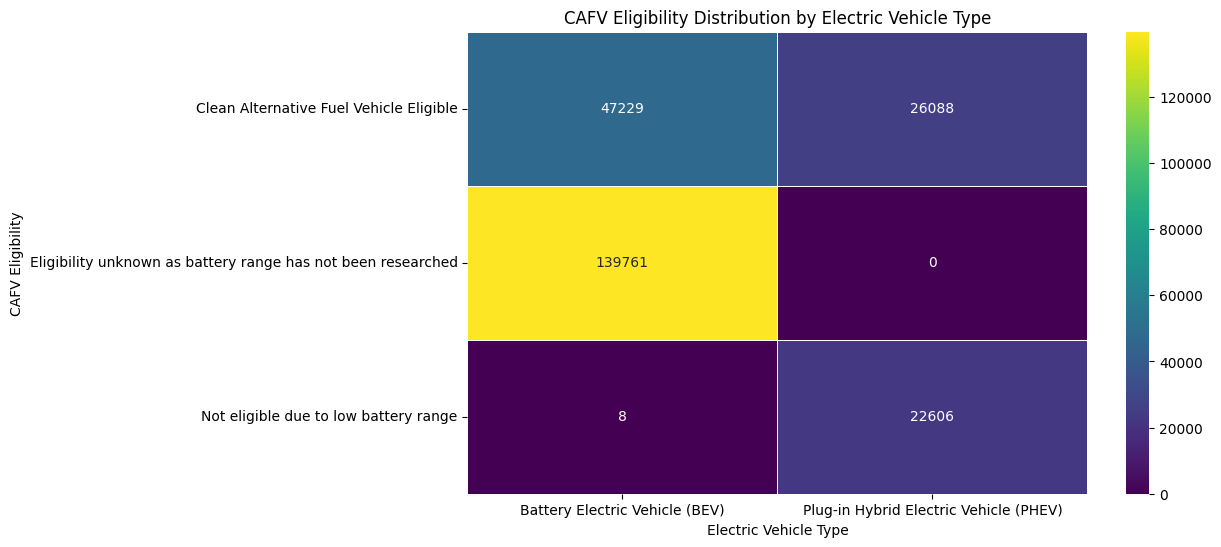

In [422]:
#CAFV Eligibility Distribution by Electric Vehicle Type

# Pivot table to count CAFV eligibility by Electric Vehicle Type
cafv_heatmap_data = df.pivot_table(index='Clean Alternative Fuel Vehicle (CAFV) Eligibility', 
                                   columns='Electric Vehicle Type', 
                                   aggfunc='size', fill_value=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cafv_heatmap_data, annot=True, cmap='viridis', fmt='d', linewidths=0.5)
plt.title('CAFV Eligibility Distribution by Electric Vehicle Type', fontsize=12)
plt.ylabel('CAFV Eligibility')
plt.xlabel('Electric Vehicle Type')
plt.show()


/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_20092/1708885021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(yr_counts, x="Model Year", y="Vehicle count", palette="viridis")


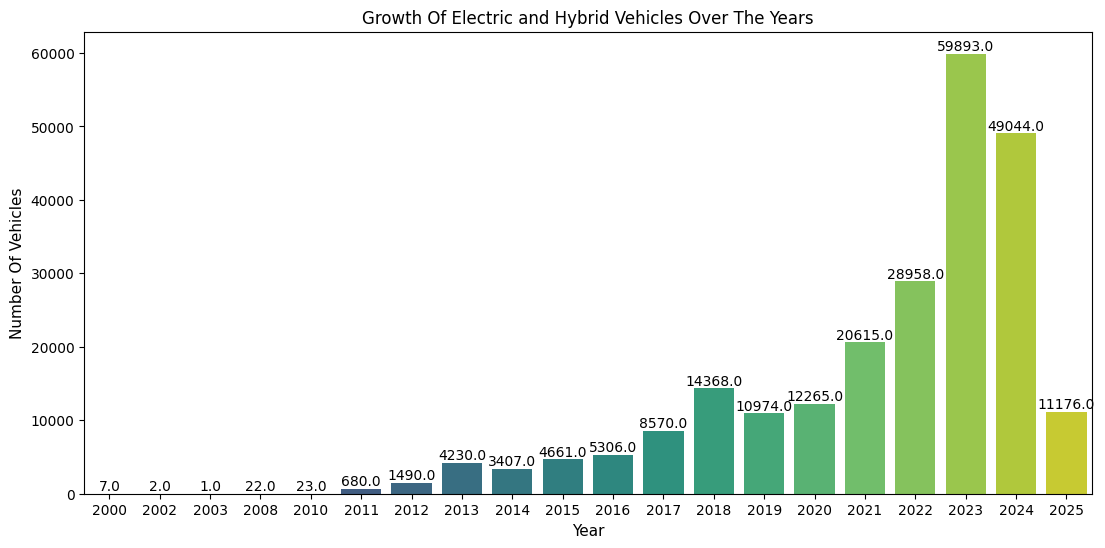

In [423]:
# Growth Of Electric and Hybrid Vehicles Over The Years

#Grouping the vehicle count by year
yr_counts = df.groupby(["Model Year"]).size().reset_index(name="Vehicle count")

#Plot the figure
plt.figure(figsize=(13,6))
barplot = sns.barplot(yr_counts, x="Model Year", y="Vehicle count", palette="viridis")
plt.xlabel("Year",fontsize=11)
plt.ylabel("Number Of Vehicles", fontsize=11)
plt.title("Growth Of Electric and Hybrid Vehicles Over The Years", fontsize=12)

#Annotate the count over the bars
for p in barplot.patches:
    barplot.annotate(f"{p.get_height()}", (p.get_x() + p.get_width() / 2, p.get_height()), va="bottom", ha="center", fontsize=10)
    
plt.show()

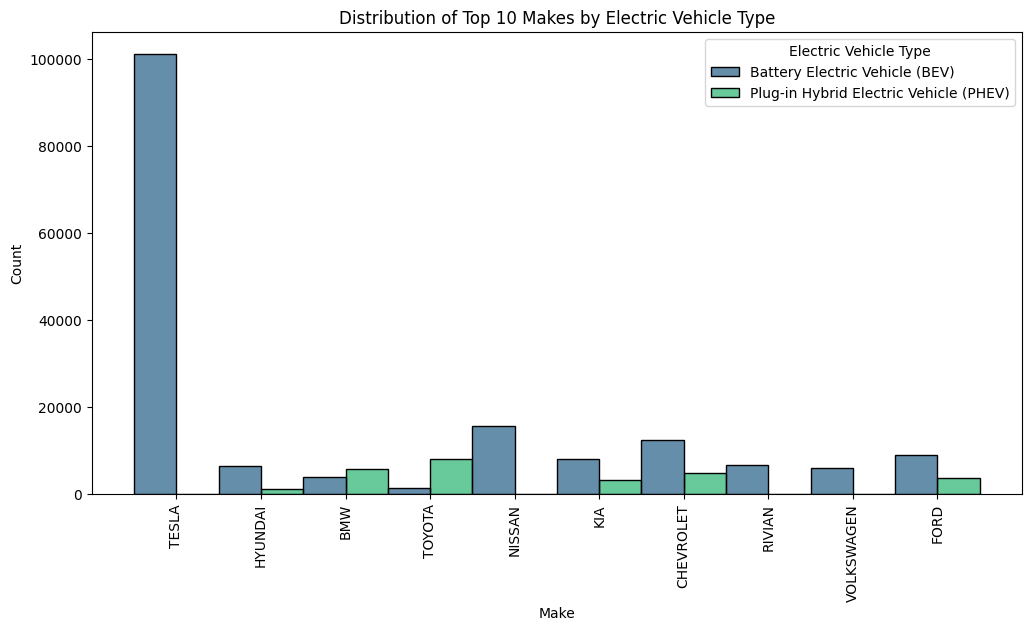

In [424]:
# Distribution of Top 10 Makes by Electric Vehicle Type

import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 makes based on the count of vehicles
top_10_makes = df['Make'].value_counts().nlargest(10).index

# Filter the dataframe to only include rows where Make is in the top 10
df_top_10 = df[df['Make'].isin(top_10_makes)]

# Create the plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_top_10, x='Make', hue='Electric Vehicle Type', multiple='dodge', palette='viridis', discrete=True)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Add title and labels
plt.title('Distribution of Top 10 Makes by Electric Vehicle Type')
plt.xlabel('Make')
plt.ylabel('Count')

# Show the plot
plt.show()


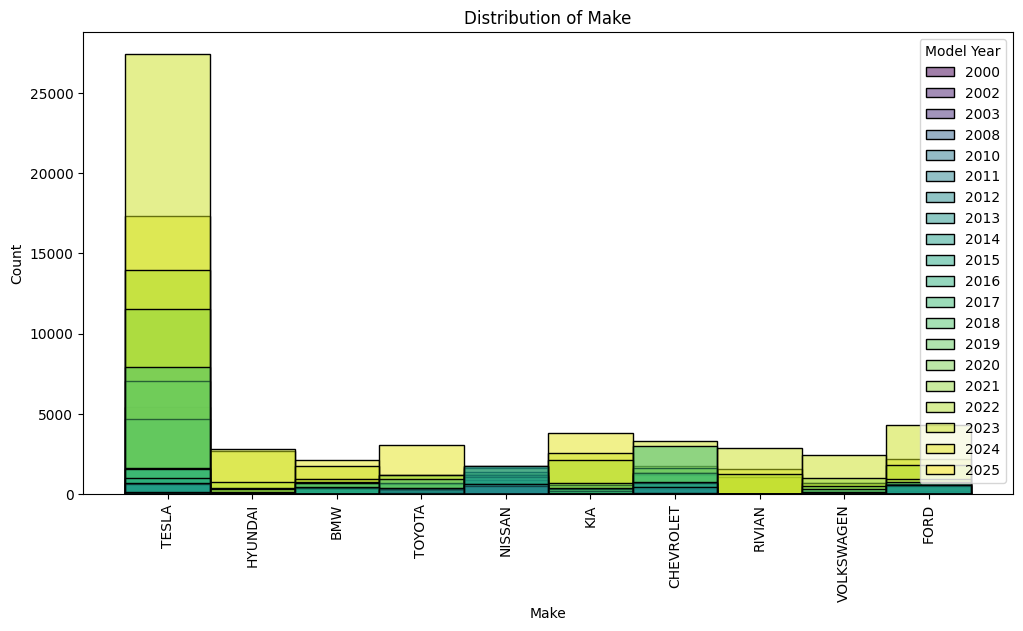

In [425]:
#Distribution of Electric Range
plt.figure(figsize=(12, 6))
sns.histplot(data =df_top_10, x='Make', bins=50, hue='Model Year', palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Make')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

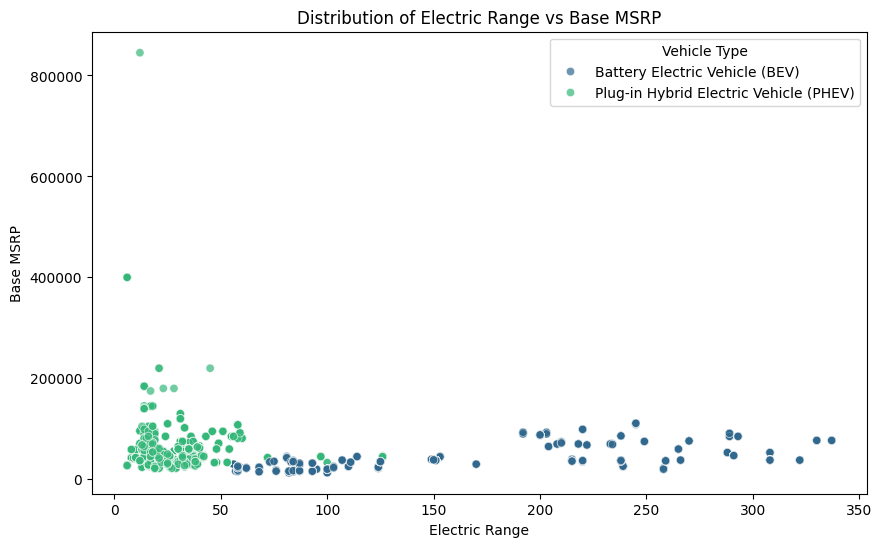

In [426]:
#Scatter plot for distribution of electric range vs Base MSRP
df_filtered = df[(df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] != 'Eligibility unknown as battery range has not been researched')]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Electric Range', y='Base MSRP', hue='Electric Vehicle Type', palette='viridis', alpha=0.7)
plt.title('Distribution of Electric Range vs Base MSRP')
plt.xlabel('Electric Range')
plt.ylabel('Base MSRP')
plt.legend(title='Vehicle Type')
plt.show()


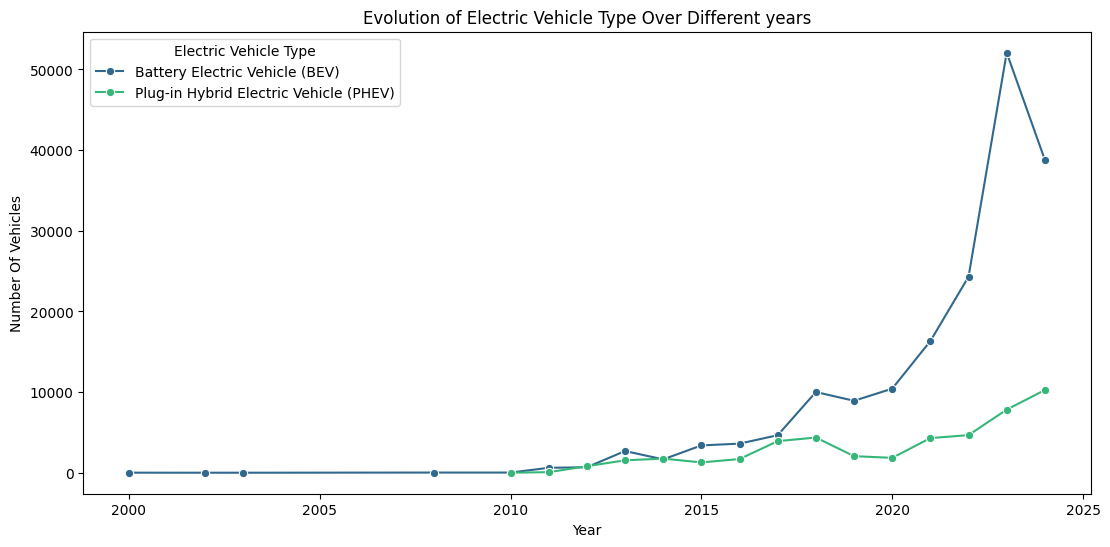

In [427]:
# Evolution of Electric Vehicle Type Over Different years

arch_per_year = df.groupby(["Electric Vehicle Type", "Model Year"]).size().reset_index(name="Vehicle count")
upto2024 = arch_per_year[arch_per_year["Model Year"] != 2025]

plt.figure(figsize=(13, 6))
lineplot = sns.lineplot(data=upto2024, x="Model Year", y="Vehicle count", hue="Electric Vehicle Type", palette="viridis", marker="o")
plt.xlabel("Year")
plt.ylabel("Number Of Vehicles")
plt.title("Evolution of Electric Vehicle Type Over Different years", fontsize=12)

plt.show()

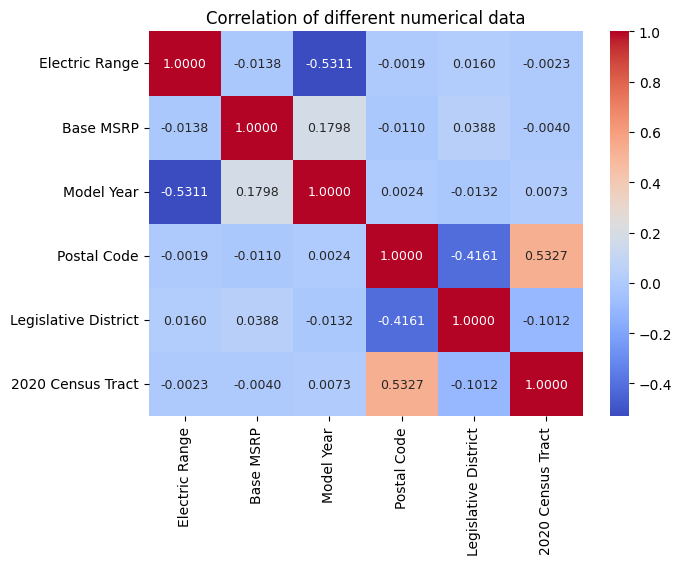

In [428]:
#Correlation matrix for the numerical data
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df[['Electric Range', 'Base MSRP', 'Model Year', 'Postal Code', 'Legislative District', '2020 Census Tract']]
corr_matrix = df_corr.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", annot_kws={"size": 9})
plt.title('Correlation of different numerical data')
plt.show()

## Data Preprocessing

In [429]:
#Drop columns that are not needed
df = df.drop(['2020 Census Tract', 'Electric Utility', 'Vehicle Location', 'Legislative District', 'VIN (1-10)', 'Postal Code'], axis=1)

#Print shape of dataframe after dropping unwanted columns
print(df.shape)

#Print count of null values in the dataframe columns
df.isnull().sum()

(235692, 11)


County                                                3
City                                                  3
State                                                 0
Model Year                                            0
Make                                                  0
Model                                                 0
Electric Vehicle Type                                 0
Clean Alternative Fuel Vehicle (CAFV) Eligibility     0
Electric Range                                       36
Base MSRP                                            36
DOL Vehicle ID                                        0
dtype: int64

In [430]:
# Categorical Imputation using Mode
df['County'] = df['County'].fillna(df['County'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Numerical Imputation using Median
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].median())
df['Base MSRP'] = df['Base MSRP'].fillna(df['Base MSRP'].median())

# Final Check for Missing Values
print(df.isnull().sum())

County                                               0
City                                                 0
State                                                0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
DOL Vehicle ID                                       0
dtype: int64


In [431]:
#Count the number of rows per state
state_counts = df['State'].value_counts().reset_index(name='Count')
state_counts.columns = ['State', 'Count']  # Rename columns for clarity
state_counts_sorted = state_counts.sort_values(by='Count', ascending=False)
state_counts_sorted.head(10)


,State,Count
0,WA,235198
1,CA,112
2,VA,62
3,MD,38
4,TX,28
5,CO,21
6,FL,19
7,NC,18
8,GA,15
10,CT,11


In [432]:
#Keep only the rows for WA state as it has the majority of records
df = df[df['State']=='WA']
print("Data of vehicles is from the state of "+df['State'].unique())

#Drop the state column as now the data is only for WA state
df = df.drop('State',axis=1)
#Print shape of dataframe
df.shape

['Data of vehicles is from the state of WA']


(235198, 10)

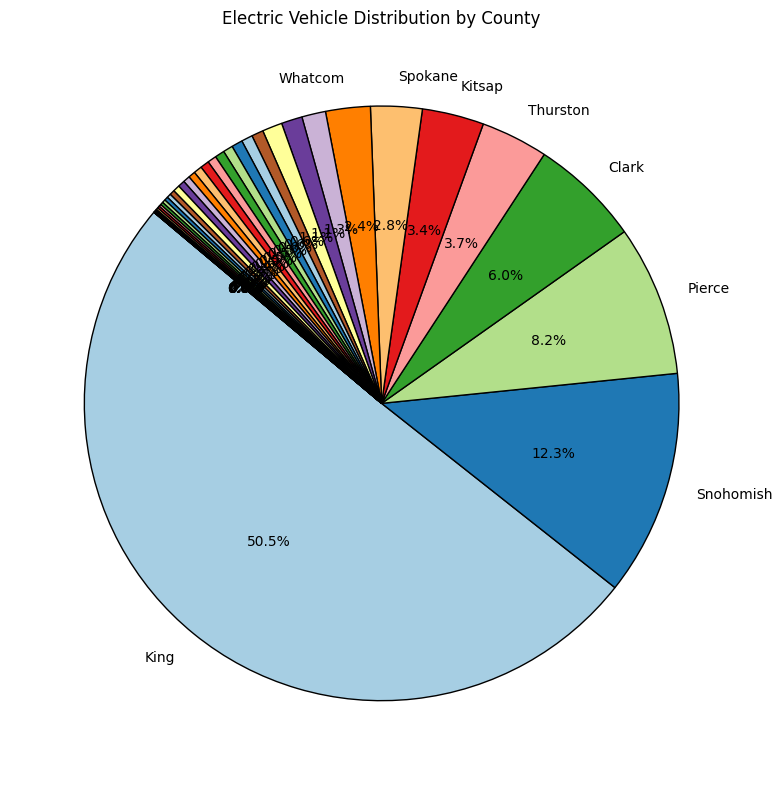

In [433]:
#Distribution of cars across different counties in Washington State

import matplotlib.pyplot as plt

# Group by County and count the number of electric vehicles per county
county_counts = df['County'].value_counts()

# Get the top 10 counties with the highest counts
top_10_counties = county_counts.head(8)

# Create a new list of labels where we only show the names for the top 10 counties
# For counties beyond top 10, the label will be an empty string
labels = [
    county if county in top_10_counties.index else ''  # Show the name only for the top 10 counties
    for county in county_counts.index
]

# Function to format the percentage for the pie chart
def func(pct, allvals):
    return f"{pct:.1f}%"

# Plot the chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    county_counts.values, 
    labels=labels,  
    autopct=lambda pct: func(pct, county_counts.values), 
    colors=plt.cm.Paired.colors, 
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

# Add title to the pie chart
plt.title('Electric Vehicle Distribution by County', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


## Feature Engineering

In [434]:

#Create a new column combining 'Make' and 'Model'
df['Make-Model'] = df['Make'] + ' ' + df['Model']

units_sold = df.groupby(['Make', 'Model', 'County'])['DOL Vehicle ID'].transform('count')

#Calculate the Popularity percentage and add it to a new column
df['Popularity Percentage'] = (units_sold / units_sold.max()) * 100

df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,477309682,TESLA MODEL 3,72.233789
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,109705683,TESLA MODEL Y,4.134444
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,0.0,40000.0,230390492,HYUNDAI IONIQ 5,0.725015
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,267929112,BMW X5,0.293724
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,236505139,TOYOTA RAV4 PRIME,0.553986


In [435]:
#Check the data types
df.dtypes

County                                                object
City                                                  object
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
DOL Vehicle ID                                         int64
Make-Model                                            object
Popularity Percentage                                float64
dtype: object

## Standard Scaling

In [436]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df[['County','City','Make','Model','Model Year','Electric Vehicle Type','Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Make-Model']]=df[['County','City','Make','Model','Model Year','Electric Vehicle Type','Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Make-Model']].astype('category')

# Create a mask for non-zero values
non_zero_mask = df['Electric Range'] > 0

# Extract the non-zero values for scaling
electric_range_non_zero = df.loc[non_zero_mask, 'Electric Range'].values.reshape(-1, 1)

# Scale only the non-zero electric range values
scaler = StandardScaler()
electric_range_scaled = scaler.fit_transform(electric_range_non_zero)

# Replace the scaled values back into the original DataFrame
df.loc[non_zero_mask, 'Electric Range'] = electric_range_scaled.flatten()

# Impute the zero values (0 or NaN) with the median of the non-zero values or any other imputation method
# We first replace zeros with NaN to treat them as missing values for imputation
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)

# Impute missing values (NaNs) with the median of non-zero values
imputer = SimpleImputer(strategy='median')
df['Electric Range'] = imputer.fit_transform(df[['Electric Range']])

# Scale Base MSRP
scaler_base = StandardScaler()
df['Base MSRP'] = scaler_base.fit_transform(df[['Base MSRP']])

print(df.dtypes)

df.head()


County                                               category
City                                                 category
Model Year                                           category
Make                                                 category
Model                                                category
Electric Vehicle Type                                category
Clean Alternative Fuel Vehicle (CAFV) Eligibility    category
Electric Range                                        float64
Base MSRP                                             float64
DOL Vehicle ID                                          int64
Make-Model                                           category
Popularity Percentage                                 float64
dtype: object


,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.079898,-0.629206,477309682,TESLA MODEL 3,72.233789
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.801150,-0.005324,109705683,TESLA MODEL Y,4.134444
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,-0.423556,-0.442041,230390492,HYUNDAI IONIQ 5,0.725015
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,-0.850212,0.805724,267929112,BMW X5,0.293724
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,-0.728310,-0.130100,236505139,TOYOTA RAV4 PRIME,0.553986


## Data Mining Techniques

### 1. Association Rule Mining

In [437]:
from mlxtend.preprocessing import TransactionEncoder

#create subset for features amongst which association rule mining is to be performed
data_subset = df[['Make-Model', 'County']]

# Preprocess data into list of transactions
transactions = data_subset.apply(lambda row: row.astype(str).values.tolist(), axis=1).tolist()

# Convert the transactions to one-hot encoded format
encoder = TransactionEncoder()
encoded_data = encoder.fit_transform(transactions)

# Create a DataFrame for the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=encoder.columns_)

encoded_df.head()


,ACURA ZDX,ALFA ROMEO TONALE,AUDI A3,AUDI A7 E,AUDI A8 E,AUDI E-TRON,AUDI E-TRON GT,AUDI E-TRON SPORTBACK,AUDI Q4,AUDI Q5,...,VOLVO V60,VOLVO XC40,VOLVO XC60,VOLVO XC90,WHEEGO ELECTRIC CARS WHEEGO,Wahkiakum,Walla Walla,Whatcom,Whitman,Yakima
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [438]:
pd.set_option('display.max_colwidth', None)

# Apply the Apriori algorithm to find frequent itemsets
from mlxtend.frequent_patterns import apriori, association_rules

# Apply the Apriori algorithm with a minimum support of 0.05
frequent_itemsets = apriori(encoded_df, min_support=0.05, use_colnames=True)

frequent_itemsets

,support,itemsets
0,0.059920,(Clark)
1,0.504728,(King)
2,0.058691,(NISSAN LEAF)
3,0.081871,(Pierce)
4,0.122510,(Snohomish)
5,0.152943,(TESLA MODEL 3)
6,0.208960,(TESLA MODEL Y)
7,0.082603,"(TESLA MODEL 3, King)"
8,0.114355,"(TESLA MODEL Y, King)"


In [439]:
# Generate association rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Display the rules
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TESLA MODEL 3),(King),0.152943,0.504728,0.082603,0.540087,1.070055,1.0,0.005408,1.076881,0.077290,0.143640,0.071393,0.351872
1,(King),(TESLA MODEL 3),0.504728,0.152943,0.082603,0.163658,1.070055,1.0,0.005408,1.012811,0.132187,0.143640,0.012649,0.351872
2,(TESLA MODEL Y),(King),0.208960,0.504728,0.114355,0.547256,1.084260,1.0,0.008887,1.093934,0.098240,0.190803,0.085868,0.386912
3,(King),(TESLA MODEL Y),0.504728,0.208960,0.114355,0.226567,1.084260,1.0,0.008887,1.022765,0.156907,0.190803,0.022258,0.386912


In [440]:
# Filter rules based on lift and confidence (optional)
filtered_rules = rules[(rules['lift'] > 1) & (rules['confidence'] > 0.5)]

# Display filtered rules
filtered_rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TESLA MODEL 3),(King),0.152943,0.504728,0.082603,0.540087,1.070055,1.0,0.005408,1.076881,0.07729,0.143640,0.071393,0.351872
2,(TESLA MODEL Y),(King),0.208960,0.504728,0.114355,0.547256,1.084260,1.0,0.008887,1.093934,0.09824,0.190803,0.085868,0.386912


Analysis:
Targeting King County: King County has a notable proportion of customers buying TESLA MODEL 3 and TESLA MODEL Y, and targeting this region could be effective for future campaigns or sales strategies.

Product Availability or Promotions: Given the higher likelihood of TESLA vehicle purchases in King County, there could be potential for tailored promotions, events, or product availability targeted specifically at King County.

### Clustering

In [441]:
import pandas as pd
from sklearn.cluster import KMeans

# Filtered the data frame to only include cars where Electric Range is known
df_filtered = df[df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] != 'Eligibility unknown as battery range has not been researched'].copy()

# Clustering based on price (Base MSRP) - Low, Medium, High, Very High
kmeans_price = KMeans(n_clusters=4, random_state=42)
df_filtered['Price Cluster'] = kmeans_price.fit_predict(df_filtered[['Base MSRP']])

# For each price cluster, perform clustering based on Electric Range (Low, High)
def cluster_by_electric_range(price_cluster, df_filtered):
    
    cluster_data = df_filtered[df_filtered['Price Cluster'] == price_cluster].copy()
    
    # Applied KMeans clustering on Electric Range within the price cluster
    kmeans_range = KMeans(n_clusters=2, random_state=42)
    cluster_data['Range Cluster'] = kmeans_range.fit_predict(cluster_data[['Electric Range']])
    
    # Update the main dataframe with the cluster results
    df_filtered.loc[df_filtered['Price Cluster'] == price_cluster, 'Range Cluster'] = cluster_data['Range Cluster']
    return df_filtered

# Apply the range clustering for each price cluster
for price_cluster in df_filtered['Price Cluster'].unique():
    df_filtered = cluster_by_electric_range(price_cluster, df_filtered)

#Create a copy of the original dataframe and merge the cluster information to it so that inverse transform can be performed on Base MSRP and Electric Range
df_clustering = df.copy()
df_clustering = pd.merge(df_clustering, df_filtered[['DOL Vehicle ID','Price Cluster', 'Range Cluster']], on='DOL Vehicle ID', how='left')

#Add the cars with unknown electric range to -1 cluster
df_clustering['Price Cluster'] = df_clustering['Price Cluster'].fillna('-1')
df_clustering['Range Cluster'] = df_clustering['Range Cluster'].fillna('-1')

#Perform inverse transform to bring back original values of Base MSRP and Electric Range
df_clustering[['Electric Range']] = scaler.inverse_transform(df[['Electric Range']])
df_clustering[['Base MSRP']] = scaler_base.inverse_transform(df[['Base MSRP']])
df_clustering.loc[df_clustering['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Eligibility unknown as battery range has not been researched', 'Electric Range'] = 0

#Print the top 5 rows showing the Price and Electric Range Clusters
df_clustering.head()


,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage,Price Cluster,Range Cluster
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,477309682,TESLA MODEL 3,72.233789,3.0,1.0
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,109705683,TESLA MODEL Y,4.134444,0.0,1.0
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,0.0,40000.0,230390492,HYUNDAI IONIQ 5,0.725015,-1,-1
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,267929112,BMW X5,0.293724,0.0,0.0
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,236505139,TOYOTA RAV4 PRIME,0.553986,0.0,0.0


In [442]:
# Group by Price Cluster and Range Cluster
cluster_stats = df_clustering.groupby(['Price Cluster', 'Range Cluster']).agg(
    min_price=('Base MSRP', 'min'),
    max_price=('Base MSRP', 'max'),
    min_range=('Electric Range', 'min'),
    max_range=('Electric Range', 'max'),
    num_cars=('Base MSRP', 'size')  # Counting number of cars in the cluster
).reset_index()

# Adding most popular car information to each cluster
def get_most_popular_car(cluster_data):
    # Find the most popular Make and Model in the cluster
    most_popular_car = cluster_data.groupby(['Make', 'Model'], observed=False).size().idxmax()
    # Get the details of the most popular car (Price and Electric Range)
    most_popular_car_data = cluster_data[(cluster_data['Make'] == most_popular_car[0]) &
                                         (cluster_data['Model'] == most_popular_car[1])]
    most_popular_car_price = most_popular_car_data['Base MSRP'].min()
    most_popular_car_range = most_popular_car_data['Electric Range'].min()
    most_popular_car_ev_type = most_popular_car_data['Electric Vehicle Type'].mode()[0]
    return most_popular_car, most_popular_car_price, most_popular_car_range, most_popular_car_ev_type

# Print cluster statistics along with most popular car details
for _, row in cluster_stats.iterrows():
    # Get the cluster data
    cluster_data = df_clustering[(df_clustering['Price Cluster'] == row['Price Cluster']) & 
                           (df_clustering['Range Cluster'] == row['Range Cluster'])]
    
    # Get most popular car info
    most_popular_car, most_popular_car_price, most_popular_car_range, most_popular_car_ev_type = get_most_popular_car(cluster_data)
    
    print(f"Price Cluster: {row['Price Cluster']}, Range Cluster: {row['Range Cluster']}:")
    print(f"  Min Price: {row['min_price']}")
    print(f"  Max Price: {row['max_price']}")
    print(f"  Min Electric Range: {row['min_range']}")
    print(f"  Max Electric Range: {row['max_range']}")
    print(f"  Total Number of Cars: {row['num_cars']}")
    
    print(f"  Most Popular Car in this Cluster: Make: {most_popular_car[0]}, Model: {most_popular_car[1]}, Price($): {most_popular_car_price}, Electric Range(miles): {most_popular_car_range}, Vehicle Type: {most_popular_car_ev_type}")
    print("-" * 40)


Price Cluster: 0.0, Range Cluster: 0.0:
  Min Price: 43700.0
  Max Price: 63000.0
  Min Electric Range: 8.0
  Max Electric Range: 153.0
  Total Number of Cars: 14384
  Most Popular Car in this Cluster: Make: TOYOTA, Model: RAV4 PRIME, Price($): 44000.0, Electric Range(miles): 42.0, Vehicle Type: Plug-in Hybrid Electric Vehicle (PHEV)
----------------------------------------
Price Cluster: 0.0, Range Cluster: 1.0:
  Min Price: 47000.0
  Max Price: 59900.0
  Min Electric Range: 265.0
  Max Electric Range: 308.0
  Total Number of Cars: 2555
  Most Popular Car in this Cluster: Make: TESLA, Model: MODEL Y, Price($): 47000.0, Electric Range(miles): 291.0, Vehicle Type: Battery Electric Vehicle (BEV)
----------------------------------------
Price Cluster: 1.0, Range Cluster: 0.0:
  Min Price: 65000.0
  Max Price: 110950.0
  Min Electric Range: 192.0
  Max Electric Range: 337.0
  Total Number of Cars: 10376
  Most Popular Car in this Cluster: Make: TESLA, Model: MODEL S, Price($): 69900.0, Ele

#### Customer Segmentation for Marketing and Sales: 

Price-Sensitive Consumers (Low Price Range - Price Cluster 0, Range Cluster 0):  

Insight: The TOYOTA RAV4 PRIME is the most popular vehicle in this cluster. With an electric range of 42 miles and a price around $44,000, it appeals to consumers looking for affordable plug-in hybrid electric vehicles (PHEVs).

Mid-Range Consumers (Medium Price Range - Price Cluster 0, Range Cluster 1):  

Insight: The TESLA MODEL Y leads in this segment, with an electric range of 291 miles. Consumers here are willing to spend more on an electric vehicle (BEV) with longer range and better technology.  

Luxury Consumers (High Price Range - Price Cluster 1, Range Cluster 0):  

Insight: The TESLA MODEL S, with an electric range of 208 miles, is popular in this segment. Consumers here value both luxury and performance in BEVs.  

Premium Consumers (High Price Range - Price Cluster 1, Range Cluster 1):  

Insight: The VOLVO XC90 PHEV leads this segment, appealing to consumers who prioritize luxury, performance, and moderate electric range (13 miles).  

Budget-Conscious Buyers (Low Price Range - Price Cluster 2, Range Cluster 0):  

Insight: The TOYOTA PRIUS PRIME, a popular plug-in hybrid, offers an electric range of 25 miles at a starting price of $30,000. This segment is more budget-sensitive while still seeking sustainable transportation options.  
 
Economical Long-Range Buyers (Medium Price Range - Price Cluster 2, Range Cluster 1):  

Insight: The KIA NIRO, a BEV with a strong electric range of 239 miles, stands out in this cluster, offering excellent value for consumers who prioritize longer electric ranges.  

Mass-Market EV Buyers (Mid-Range Price Range - Price Cluster 3, Range Cluster 0):  

Insight: The NISSAN LEAF, a popular BEV with an electric range of 73 miles, leads in this cluster. It appeals to consumers looking for an affordable, environmentally friendly vehicle with moderate electric range.  

Tech-Savvy, Range-Focused Consumers (Mid-Range Price Range - Price Cluster 3, Range Cluster 1):  

Insight: The TESLA MODEL 3 is the most popular vehicle in this segment, offering a longer electric range (215 miles) at a mid-range price point.  

Unknown Range or Outlier Vehicles (Price Cluster -1, Range Cluster -1):  

Insight: The TESLA MODEL Y is the most popular vehicle here, but with an electric range of 0 miles, indicating these cars likely belong to another category or are part of outliers in the data. This may represent missing or incomplete data for some vehicles.  

#### Growth Opportunities for EV Infrastructure:  
Expanding Charging Infrastructure for Long-Range EVs: With increasing adoption of BEVs like TESLA (Price Cluster 1, Range Cluster 1), the demand for charging infrastructure, particularly in urban areas, is expected to grow.


### Random Forest Classification

In [443]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = df[['Make', 'Model', 'Electric Range', 'Model Year']]
y = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encoding for categorical features (Make and Model)
X_train_encoded = pd.get_dummies(X_train[['Make', 'Model']], drop_first=True)
X_test_encoded = pd.get_dummies(X_test[['Make', 'Model']], drop_first=True)

# Align the columns of train and test sets by reindexing (ensuring same columns)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Check the columns of X_train_encoded and X_test_encoded
print("Training set columns:")
print(X_train_encoded.columns)
print("\nTest set columns:")
print(X_test_encoded.columns)

# Fit the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_encoded, y_train)

# Evaluate on the test set
y_pred = rf_classifier.predict(X_test_encoded)
'''
# Print predictions and evaluate accuracy
print("\nPredictions:", y_pred)
print("\nTrue values:", y_test.values)'''
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

result_df = pd.DataFrame({
    'Make': X_test.index.map(lambda x: df.loc[x, 'Make']),  
    'Model': X_test.index.map(lambda x: df.loc[x, 'Model']), 
    'Actual CAFV Value': y_test,
    'Prediction': y_pred
})

# Print the result DataFrame
result_df.head()


Training set columns:
Index(['Make_ALFA ROMEO', 'Make_AUDI', 'Make_AZURE DYNAMICS', 'Make_BENTLEY',
       'Make_BMW', 'Make_BRIGHTDROP', 'Make_CADILLAC', 'Make_CHEVROLET',
       'Make_CHRYSLER', 'Make_DODGE',
       ...
       'Model_WHEEGO', 'Model_WRANGLER', 'Model_X3', 'Model_X5', 'Model_XC40',
       'Model_XC60', 'Model_XC90', 'Model_XM', 'Model_ZDX', 'Model_ZEVO'],
      dtype='object', length=215)

Test set columns:
Index(['Make_ALFA ROMEO', 'Make_AUDI', 'Make_AZURE DYNAMICS', 'Make_BENTLEY',
       'Make_BMW', 'Make_BRIGHTDROP', 'Make_CADILLAC', 'Make_CHEVROLET',
       'Make_CHRYSLER', 'Make_DODGE',
       ...
       'Model_WHEEGO', 'Model_WRANGLER', 'Model_X3', 'Model_X5', 'Model_XC40',
       'Model_XC60', 'Model_XC90', 'Model_XM', 'Model_ZDX', 'Model_ZEVO'],
      dtype='object', length=215)
Accuracy: 0.8540603741496599


,Make,Model,Actual CAFV Value,Prediction
86018,VOLVO,XC40,Eligibility unknown as battery range has not been researched,Eligibility unknown as battery range has not been researched
103035,KIA,EV6,Eligibility unknown as battery range has not been researched,Eligibility unknown as battery range has not been researched
231549,JEEP,WRANGLER,Not eligible due to low battery range,Not eligible due to low battery range
92568,TESLA,MODEL 3,Eligibility unknown as battery range has not been researched,Eligibility unknown as battery range has not been researched
210548,KIA,SOUL,Clean Alternative Fuel Vehicle Eligible,Clean Alternative Fuel Vehicle Eligible


### Regression

XGBoost Regressor Mean Squared Error (MSE): 0.030772745552255093
XGBoost Regressor Root Mean Squared Error (RMSE): 0.17542162224838503
XGBoost Regressor R-squared (R2): 0.9999737541286063


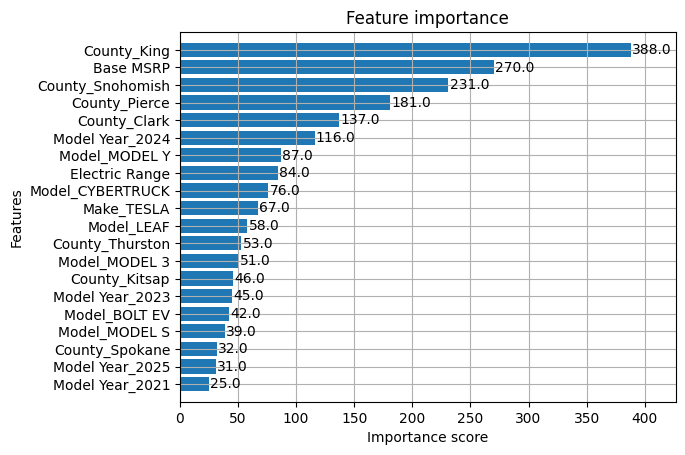

In [444]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Encode categorical variables (e.g., Make, Model, County)
df_encoded = pd.get_dummies(df[['Make', 'Model', 'Model Year', 'County']], drop_first=True)

# Add numerical features like Electric Range, Base MSRP, Popularity Percentage.
df_encoded['Electric Range'] = df['Electric Range']
df_encoded['Base MSRP'] = df['Base MSRP']
df_encoded['Popularity Percentage'] = df['Popularity Percentage']

# Define the target variable (Popularity as a continuous score)
X = df_encoded.drop(['Popularity Percentage'], axis=1)  # Features
y = df_encoded['Popularity Percentage']  # Target is the popularity score

# Standardize the 'Electric Range' and 'Base MSRP' columns
scaler = StandardScaler()
X[['Electric Range', 'Base MSRP']] = scaler.fit_transform(X[['Electric Range', 'Base MSRP']])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor for Popularity Score Prediction (0 to 100%)
xgb_regressor = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_regressor.predict(X_test)

y_pred_df = pd.DataFrame(y_pred_xgb, columns=['Predicted Popularity Percentage'])
X_test['Predicted Popularity Percentage'] = y_pred_df

# combine the predictions with the original test set data
result_df = X_test.copy()
result_df['Actual Popularity Percentage'] = y_test  # Actual popularity score from the test set

# Evaluate XGBoost Regressor Model
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Mean Squared Error (MSE): {mse}")
print(f"XGBoost Regressor Root Mean Squared Error (RMSE): {rmse}")
print(f"XGBoost Regressor R-squared (R2): {r2}")

# Feature Importance
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_regressor,max_num_features=20, importance_type='weight', height=0.8)
plt.show()


In [445]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_regressor, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-validated MSE: {-scores.mean()}")


Cross-validated MSE: 0.033260529245469045
